In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("customer_feedback.csv")

print(df.head())

                                          Feedback           Category
0            Wrong color received and I need help.            Product
1        Gift wrapping available for order #82633.    General Inquiry
2   Checkout page not loading for my recent order.  Technical Support
3        Package not received on my first attempt.           Delivery
4  Password reset not working as soon as possible.  Technical Support


In [4]:
X = df["Feedback"]

y = df["Category"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

In [7]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('classifier', MultinomialNB())])

In [8]:
predictions = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [10]:
print(classification_report(y_test, predictions))

                   precision    recall  f1-score   support

          Billing       1.00      1.00      1.00        36
         Delivery       1.00      1.00      1.00        49
  General Inquiry       1.00      1.00      1.00        35
          Product       1.00      1.00      1.00        34
Technical Support       1.00      1.00      1.00        46

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



In [11]:
new_feedback = [
    "I have not received my order."
]

prediction = model.predict(new_feedback)

print("Predicted Category:", prediction[0])

Predicted Category: Product


In [13]:
new_feedback = [
    "My account password is not working."
]

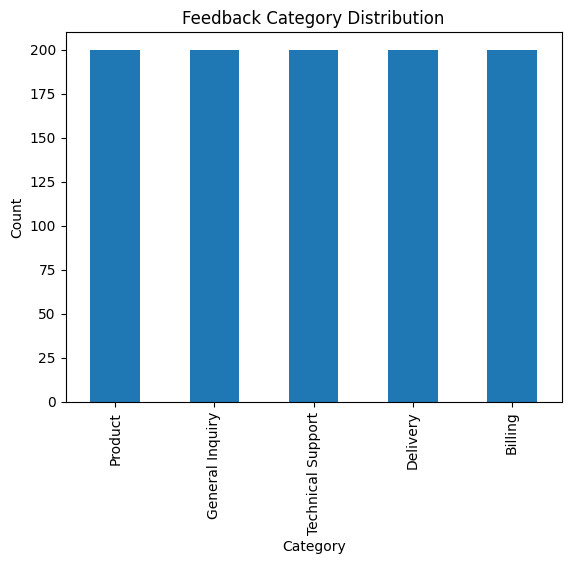

In [14]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")

plt.title("Feedback Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

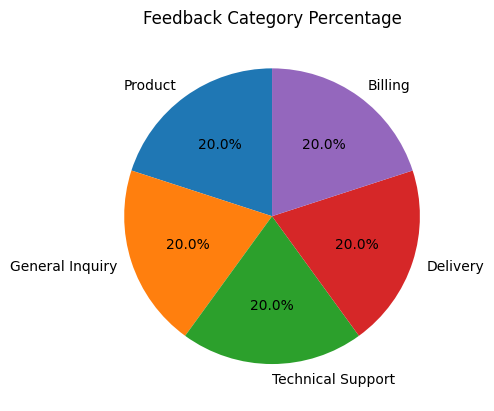

In [15]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Feedback Category Percentage")
plt.ylabel("")
plt.show()